# 🫁 NIH ChestX-ray14 — Conversión PNG → Tensores .pt
**Input:** `proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/nih/images224/`  
**Output:** `proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/nih/tensores224/`

**Transformación aplicada (idéntica a `val_tfm_2d` del notebook MoE):**
- Resize 224×224 (por seguridad aunque ya lo sean)
- ToTensor → `float32` en `[0, 1]`
- Normalize ImageNet (`mean=[0.485,0.456,0.406]`, `std=[0.229,0.224,0.225]`)

**Formato por archivo:** `{nombre_imagen}.pt` → tensor `[3, 224, 224]` float32  
Compatible directamente con `NIHDataset` y `ExpertNIH` del notebook MoE.

In [1]:
!pip install torch torchvision Pillow tqdm --quiet

In [2]:
import os
import torch
import torchvision.transforms as T
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── Rutas ─────────────────────────────────────────────────────────────────────
BASE = Path("DATA/nih")

INPUT_DIR  = BASE / "images224"    # carpeta con los .png originales
OUTPUT_DIR = BASE / "tensores224"  # carpeta destino para los .pt

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT_DIR.exists(), (
    f"ERROR: no se encontro la carpeta de entrada:\n  {INPUT_DIR.resolve()}\n"
    "Verifica que la ruta sea correcta."
)

png_files = sorted(INPUT_DIR.glob("*.png"))
print(f"Carpeta entrada  : {INPUT_DIR.resolve()}")
print(f"Carpeta salida   : {OUTPUT_DIR.resolve()}")
print(f"Imagenes .png    : {len(png_files):,}")

if len(png_files) == 0:
    raise ValueError("No se encontraron archivos .png en INPUT_DIR — revisa la ruta.")

Carpeta entrada  : /proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/nih/images224
Carpeta salida   : /proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/nih/tensores224
Imagenes .png    : 112,120


In [3]:
# ── Transformacion ImageNet (igual que val_tfm_2d del notebook MoE) ─────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transformacion definida:")
print("  Resize    → 224x224")
print("  ToTensor  → [3, 224, 224] float32 en [0, 1]")
print(f"  Normalize → mean={IMAGENET_MEAN}")
print(f"              std={IMAGENET_STD}")
print()

# Verificar con la primera imagen
sample_img = Image.open(png_files[0]).convert("RGB")
sample_t   = transform(sample_img)

print(f"Verificacion con: {png_files[0].name}")
print(f"  PIL size  : {sample_img.size}  modo: {sample_img.mode}")
print(f"  Tensor    : {list(sample_t.shape)}  dtype: {sample_t.dtype}")
print(f"  Rango     : [{sample_t.min():.4f}, {sample_t.max():.4f}]")

assert sample_t.shape == torch.Size([3, 224, 224]), \
    f"ERROR: shape inesperado {sample_t.shape}, esperado [3, 224, 224]"
print("\n✅ Transformacion OK — listo para convertir")

Transformacion definida:
  Resize    → 224x224
  ToTensor  → [3, 224, 224] float32 en [0, 1]
  Normalize → mean=[0.485, 0.456, 0.406]
              std=[0.229, 0.224, 0.225]

Verificacion con: 00000001_000.png
  PIL size  : (224, 224)  modo: RGB
  Tensor    : [3, 224, 224]  dtype: torch.float32
  Rango     : [-2.1179, 2.6400]

✅ Transformacion OK — listo para convertir


In [5]:
# ── Deteccion de archivos ya convertidos (permite reanudar si se interrumpe) ─
already_done = set(p.stem for p in OUTPUT_DIR.glob("*.pt"))
pending      = [p for p in png_files if p.stem not in already_done]

print(f"Total imagenes   : {len(png_files):,}")
print(f"Ya convertidas   : {len(already_done):,}")
print(f"Pendientes       : {len(pending):,}")

# Cambiar a True para reconvertir todo aunque ya exista
FORCE_RECONVERT = False

if FORCE_RECONVERT:
    pending = png_files
    print("\n⚠  FORCE_RECONVERT=True — se reconvertira todo desde cero")
else:
    print("\nFORCE_RECONVERT=False — se saltan las ya convertidas")

Total imagenes   : 112,120
Ya convertidas   : 82,259
Pendientes       : 29,861

FORCE_RECONVERT=False — se saltan las ya convertidas


In [6]:
# ── Conversion principal PNG → .pt ───────────────────────────────────────────
errors    = []
converted = 0

print(f"Iniciando conversion de {len(pending):,} imagenes...\n")

for img_path in tqdm(pending, desc="PNG → .pt"):

    out_path = OUTPUT_DIR / (img_path.stem + ".pt")

    try:
        # 1. Abrir y forzar RGB (cubre grises, RGBA, paleta)
        img = Image.open(img_path).convert("RGB")

        # 2. Aplicar transformacion
        tensor = transform(img)   # [3, 224, 224] float32

        # 3. Guardar
        torch.save(tensor, out_path)
        converted += 1

    except Exception as e:
        errors.append((img_path.name, str(e)))

# ── Resumen ───────────────────────────────────────────────────────────────────
print()
print("=" * 55)
print("  CONVERSION COMPLETADA")
print("=" * 55)
print(f"  Imagenes convertidas : {converted:,}")
print(f"  Errores              : {len(errors)}")
print(f"  Destino              : {OUTPUT_DIR.resolve()}")

if errors:
    print(f"\n⚠  Imagenes con error ({len(errors)}):")
    for name, err in errors[:20]:
        print(f"    {name}: {err}")
    if len(errors) > 20:
        print(f"    ... y {len(errors) - 20} mas")

Iniciando conversion de 29,861 imagenes...



PNG → .pt:   0%|          | 0/29861 [00:00<?, ?it/s]


  CONVERSION COMPLETADA
  Imagenes convertidas : 29,861
  Errores              : 0
  Destino              : /proyecto-2-de-mierda/proyecto-2-de-mierda/DATA/nih/tensores224


In [7]:
# ── Verificacion del output ──────────────────────────────────────────────────
import random

pt_files = sorted(OUTPUT_DIR.glob("*.pt"))
print(f"Archivos .pt generados: {len(pt_files):,}")
print(f"Imagenes .png originales: {len(png_files):,}")
print()

# Verificar 5 tensores aleatorios
sample_pts = random.sample(pt_files, min(5, len(pt_files)))

print(f"  {'Archivo':<42} {'Shape':<16} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("  " + "-" * 88)

all_ok = True
for pt_path in sample_pts:
    t        = torch.load(pt_path, map_location="cpu")
    shape_ok = (t.shape == torch.Size([3, 224, 224]))
    dtype_ok = (t.dtype == torch.float32)
    ok       = shape_ok and dtype_ok
    if not ok:
        all_ok = False
    status = "OK" if ok else "ERROR"
    print(f"  [{status}] {pt_path.name:<40} {str(list(t.shape)):<16}"
          f" {t.min():>8.4f} {t.max():>8.4f} {t.mean():>8.4f}")

print()
if all_ok:
    print("✅ Verificacion OK — shape [3,224,224], dtype float32")
else:
    print("❌ Hay tensores con problemas — revisar errores arriba")

# Espacio en disco
total_mb = sum(p.stat().st_size for p in pt_files) / 1e6
print(f"\nEspacio total  : {total_mb:.1f} MB  ({total_mb/1024:.2f} GB)")
print(f"Tamano por .pt : {total_mb/max(len(pt_files),1)*1024:.1f} KB (promedio)")

Archivos .pt generados: 112,120
Imagenes .png originales: 112,120

  Archivo                                    Shape                 Min      Max     Mean
  ----------------------------------------------------------------------------------------
  [OK] 00001338_001.pt                          [3, 224, 224]     -2.1179   2.6400   0.3176
  [OK] 00013176_008.pt                          [3, 224, 224]     -2.1008   2.3960  -0.0187
  [OK] 00005873_000.pt                          [3, 224, 224]     -1.4843   2.4308   0.8534
  [OK] 00022880_004.pt                          [3, 224, 224]     -2.1179   2.5006   0.2038
  [OK] 00015563_016.pt                          [3, 224, 224]     -2.1179   2.3960   0.3846

✅ Verificacion OK — shape [3,224,224], dtype float32

Espacio total  : 67682.9 MB  (66.10 GB)
Tamano por .pt : 618.2 KB (promedio)


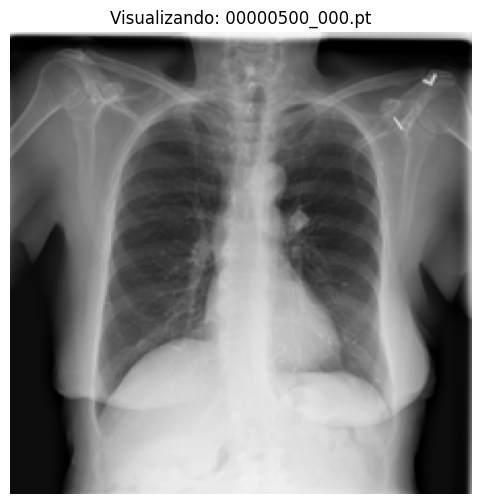

In [16]:
import torch
import matplotlib.pyplot as plt

# 1. Configuración de desnormalización (valores de tu notebook)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

# 2. Cargar un tensor de tu carpeta de salida
# Cambia el nombre por uno que exista en tu carpeta 'tensores224'
ruta_tensor = "DATA/nih/tensores224/00000500_000.pt"
tensor = torch.load(ruta_tensor) # Carga el tensor [3, 224, 224]

# 3. Desnormalizar: (Tensor * std) + mean
# Usamos [:, None, None] para que las dimensiones coincidan
tensor_rescatado = tensor * std[:, None, None] + mean[:, None, None]

# 4. Limitar valores al rango [0, 1] por seguridad
tensor_rescatado = torch.clamp(tensor_rescatado, 0, 1)

# 5. Visualizar
# Recordar: PyTorch es (C, H, W) -> Matplotlib necesita (H, W, C)
plt.figure(figsize=(6, 6))
plt.imshow(tensor_rescatado.permute(1, 2, 0))
plt.title(f"Visualizando: {ruta_tensor.split('/')[-1]}")
plt.axis('off')
plt.show()

In [ ]:
# ── Como usar los tensores desde NIHDataset en el notebook MoE ───────────────
#
# En NIHDataset.__getitem__ reemplazar la carga con PIL por esto:
#
#   tensor_path = OUTPUT_DIR / (img_name.replace(".png", ".pt"))
#   if tensor_path.exists():
#       img_tensor = torch.load(tensor_path, map_location="cpu")
#   else:
#       # fallback: convierte en tiempo real si no existe el .pt
#       img_tensor = transform(Image.open(img_path).convert("RGB"))
#   return img_tensor, label_vec, self.EXPERT_ID
#
# Ventajas del cache .pt:
#   - Evita abrir y transformar la imagen en cada epoch
#   - La lectura de .pt es ~10x mas rapida que PIL + transform
#   - Identico a la estrategia usada para LUNA16 (_pixels.npy)

# Prueba de carga directa
pt_sample = pt_files[0]
loaded    = torch.load(pt_sample, map_location="cpu")
print(f"Prueba de carga: {pt_sample.name}")
print(f"  Shape : {list(loaded.shape)}")
print(f"  Dtype : {loaded.dtype}")
print(f"  Rango : [{loaded.min():.4f}, {loaded.max():.4f}]")
print()
print("Los tensores estan listos para NIHDataset y ExpertNIH.")